In [3]:
import os
import glob

ncs = glob.glob('/dmidata/projects/ai4arctic/asidv3/dataset_files/*_EW_*.nc')

n = 1


In [4]:
zip_file = os.path.join('/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/', os.path.basename(ncs[n]).split('_icechart_')[0] + '.zip')

In [5]:
from eoutils import S1Processor

s1p = S1Processor(zip_file)

HH, HV = s1p.process()

[INFO: 2025-11-26 10:30:12: eoutils.S1Processor] Processesing started for S1A_EW_GRDM_1SDH_20210831T212250_20210831T212330_039479_04AA31_E926.zip
[INFO: 2025-11-26 10:30:12: eoutils.S1Processor] Processing band 1/2: HH
[INFO: 2025-11-26 10:30:15: eoutils.S1Processor] Calibration and thermal noise removal...
/dmidata/users/cgf/miniforge3/envs/landfastice/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
[INFO: 2025-11-26 10:30:16: eoutils.S1Processor] Converting to dB...
[INFO: 2025-11-26 10:30:17: eoutils.S1Processor] Processing band 2/2: HV
[INFO: 2025-11-26 10:30:19: eoutils.S1Processor] Calibration and thermal noise removal...
[INFO: 2025-11-26 10:30:20: eoutils.S1Processor] Converting to dB...
[INFO: 2025-11-26 10:30:21: eoutils.S1Processor] Processing finished in 8.79s.


In [8]:
s1p._transform_gcps(target_epsg=3411)

/dmidata/users/cgf/miniforge3/envs/landfastice/lib/python3.10/site-packages/osgeo/osr.py:410: FutureWarning: Neither osr.UseExceptions() nor osr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [9]:
geometry = s1p._get_gcps_as_geopandas_df().union_all().convex_hull

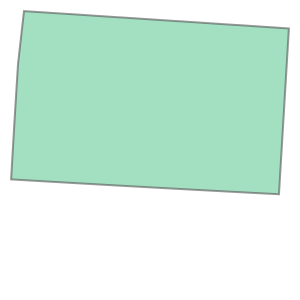

In [10]:
geometry

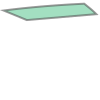

In [7]:
geometry

In [ ]:
geometry.intersects(new_sar_file)

In [ ]:
for sarimage in the folder:
    convez.intersects

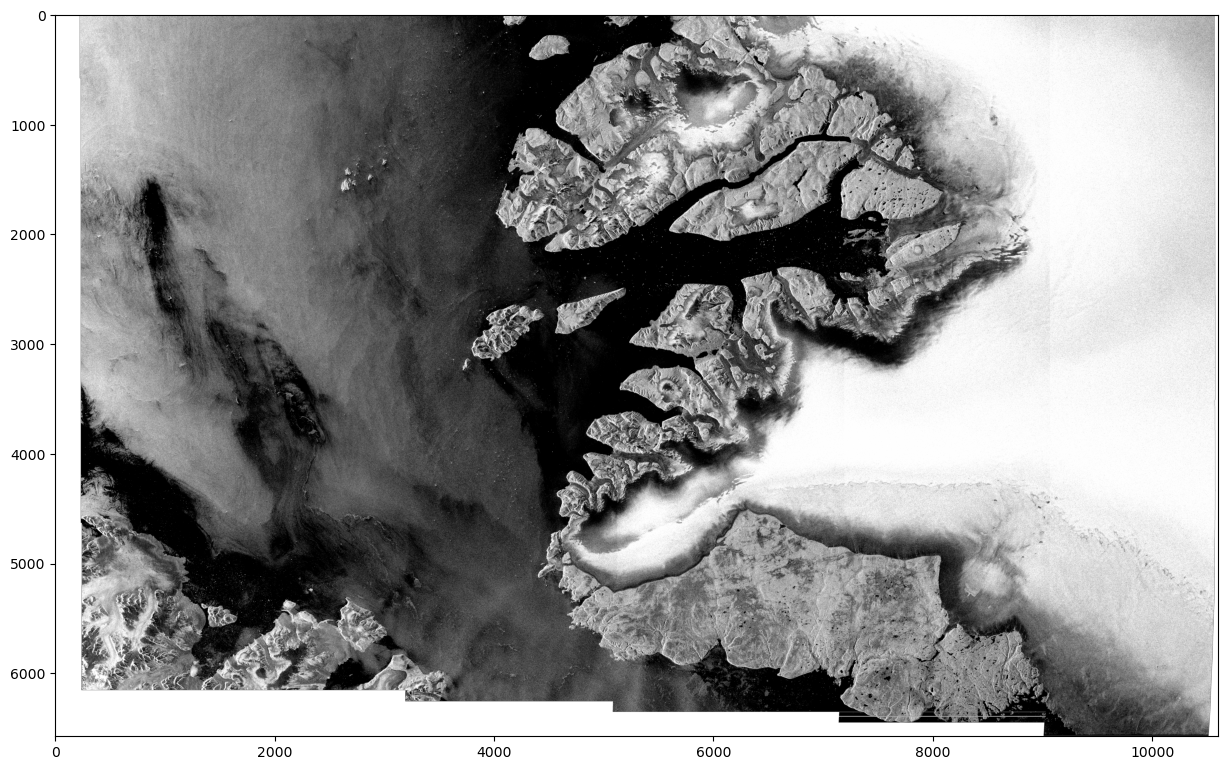

In [49]:
import matplotlib.pyplot as plt

import numpy as np

plt.figure(figsize=(15, 15))
plt.imshow(HH, vmin=np.nanpercentile(HH, 10), vmax=np.nanpercentile(HH, 90), cmap='gist_gray')

In [ ]:
glob.glob('/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/*.zip')

['/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/S1A_EW_GRDM_1SDH_20201111T211237_20201111T211337_035206_041C59_67F8.zip',
 '/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/S1B_EW_GRDM_1SDH_20210505T201118_20210505T201218_026774_0332C4_80DF.zip',
 '/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/S1A_EW_GRDM_1SDH_20191201T205227_20191201T205332_030160_037250_2BC8.zip',
 '/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/S1B_EW_GRDM_1SDH_20190705T115253_20190705T115353_016998_01FFB1_5D56.zip',
 '/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/S1B_EW_GRDM_1SDH_20210827T210357_20210827T210457_028437_0364A8_1E0F.zip',
 '/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/S1A_EW_GRDM_1SDH_20200302T033021_20200302T033125_031491_03A06B_E057.zip',
 '/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/S1A_EW_GRDM_1SDH_20201213T120211_20201213T120311_035667_042C38_F8B0.zip',
 '/dmidata/projects/ai4arctic/asidv3/sentinel1_raw/S1A_EW_GRDM_1SDH_20190327T032305_20190327T032405_026518_02F892_A5B3.zip',


In [50]:
import xarray as xr 

ds = xr.open_dataset(ncs[1])


In [51]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:                  (sar_samples: 10598, sar_lines: 6575,
                              sar_grid_points: 315, polygon_codes: 4,
                              2km_grid_lines: 131, 2km_grid_samples: 211)
Coordinates:
  * polygon_codes            (polygon_codes) <U56 896B 'poly_id;CT;CA;SA;FA;C...
Dimensions without coordinates: sar_samples, sar_lines, sar_grid_points,
                                2km_grid_lines, 2km_grid_samples
Data variables: (12/34)
    sar_incidenceangles      (sar_samples) float32 42kB ...
    sar_primary              (sar_lines, sar_samples) float32 279MB ...
    sar_secondary            (sar_lines, sar_samples) float32 279MB ...
    sar_grid_line            (sar_grid_points) float64 3kB ...
    sar_grid_sample          (sar_grid_points) float64 3kB ...
    sar_grid_latitude        (sar_grid_points) float64 3kB ...
    ...                       ...
    u10m_rotated             (2km_grid_lines, 2km_grid_samples) float64 221kB ...
    v10m_rotated             (2km_grid_lines, 2km_grid_samples) float64 221kB ...
    t2m                      (2km_grid_lines, 2km_grid_samples) float64 221kB ...
    skt                      (2km_grid_lines, 2km_grid_samples) float64 221kB ...
    tcwv                     (2km_grid_lines, 2km_grid_samples) float64 221kB ...
    tclw                     (2km_grid_lines, 2km_grid_samples) float64 221kB ...
Attributes:
    aoi_upperleft_line:     6576
    aoi_upperleft_sample:   10599
    aoi_lowerright_line:    1
    aoi_lowerright_sample:  1
    title:                  Training data file from ASIDv3 dataset\nInput: Se...
    version:                DMI 2023, noise correction ESA IPF_v3.10
    geometric_info:         All variables are gridded to match SAR bands geog...

In [52]:
ic = ds['polygon_icechart'].values

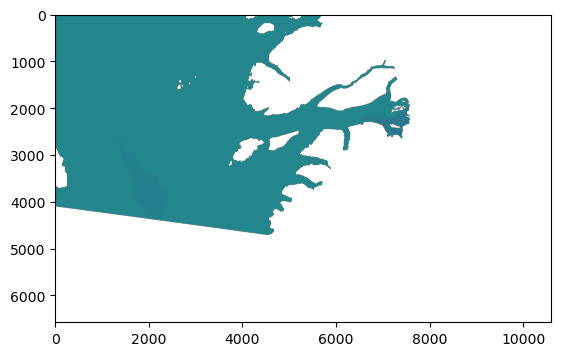

In [53]:
import matplotlib.pyplot as plt

plt.imshow(ic, vmin=0, vmax=50)

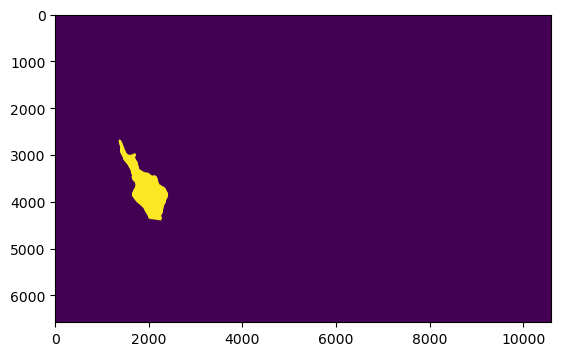

In [54]:
plt.imshow(ic == 22)

In [24]:
import numpy as np

np.unique(ic)

array([20., 22., 23., nan], dtype=float32)

In [26]:
ds['polygon_codes']

<xarray.DataArray 'polygon_codes' (polygon_codes: 4)> Size: 896B
array(['poly_id;CT;CA;SA;FA;CB;SB;FB;CC;SC;FC;CN;CD;CF;POLY_TYPE',
       '20;30;-9;98;10;-9;-9;-9;-9;-9;-9;-9;-9;19;I',
       '22;20;-9;95;3;-9;-9;-9;-9;-9;-9;98;-9;19;I',
       '23;-9;-9;-9;-9;-9;-9;-9;-9;-9;-9;-9;-9;-9;W'], dtype='<U56')
Coordinates:
  * polygon_codes  (polygon_codes) <U56 896B 'poly_id;CT;CA;SA;FA;CB;SB;FB;CC...
Attributes:
    icechart_id:  202108312120_Qaanaaq_RIC

In [29]:
hh = ds['sar_secondary'].values

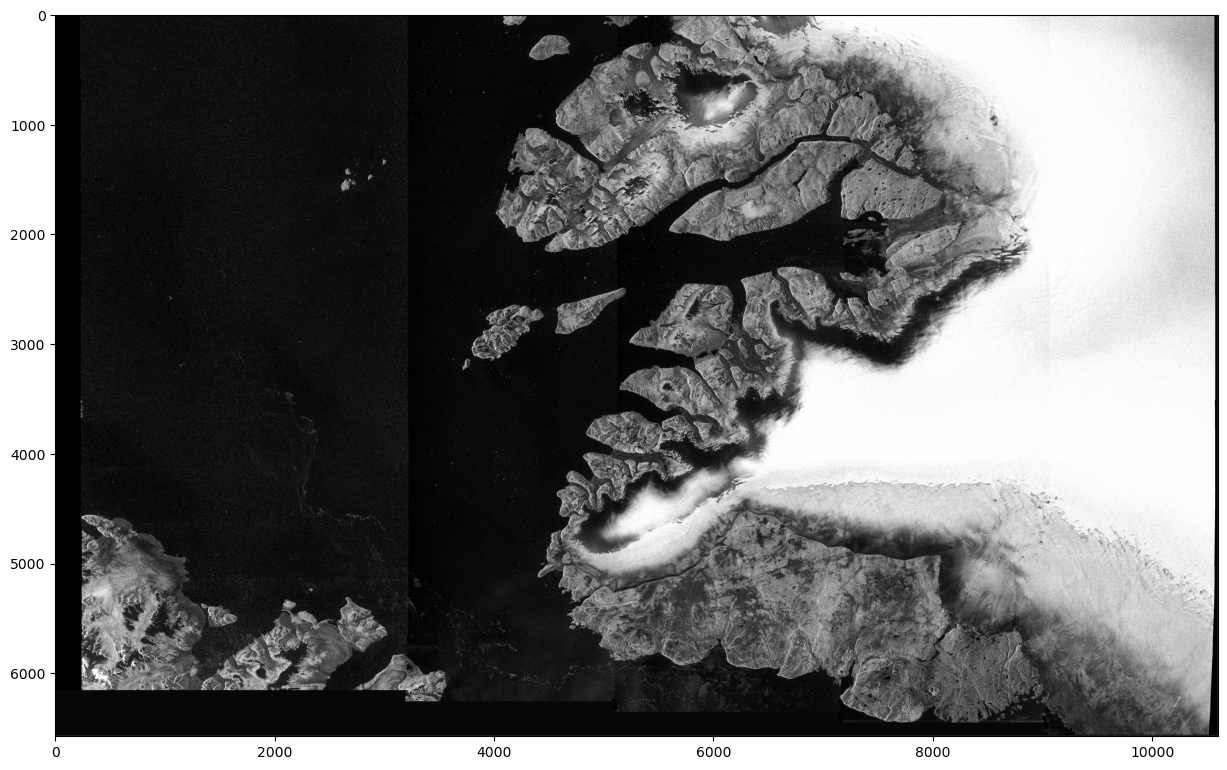

In [33]:
plt.figure(figsize=(15, 15))
plt.imshow(hh, vmin=np.nanpercentile(hh, 10), vmax=np.nanpercentile(hh, 90), cmap='gist_gray')